In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas_market_calendars as mcal

In [3]:
y = (
    pd.read_csv("../data/ixic.csv", index_col=0, parse_dates=True)
    .squeeze("columns")
    .sort_index()
)

y.name = "^IXIC"
y = y.asfreq("B").ffill()
y.index.freq = "B"
print("Start:", y.index.min().date(), "End:", y.index.max().date(), "N:", len(y))
y.tail()

Start: 2016-01-04 End: 2026-02-20 N: 2645


Date
2026-02-16    22546.669922
2026-02-17    22578.380859
2026-02-18    22753.630859
2026-02-19    22682.730469
2026-02-20    22886.070312
Freq: B, Name: ^IXIC, dtype: float64

We use NASDAQ index level.

We standardize the series to business day frequency and forward-fill non-trading days so ARIMA has a consistent time grid.

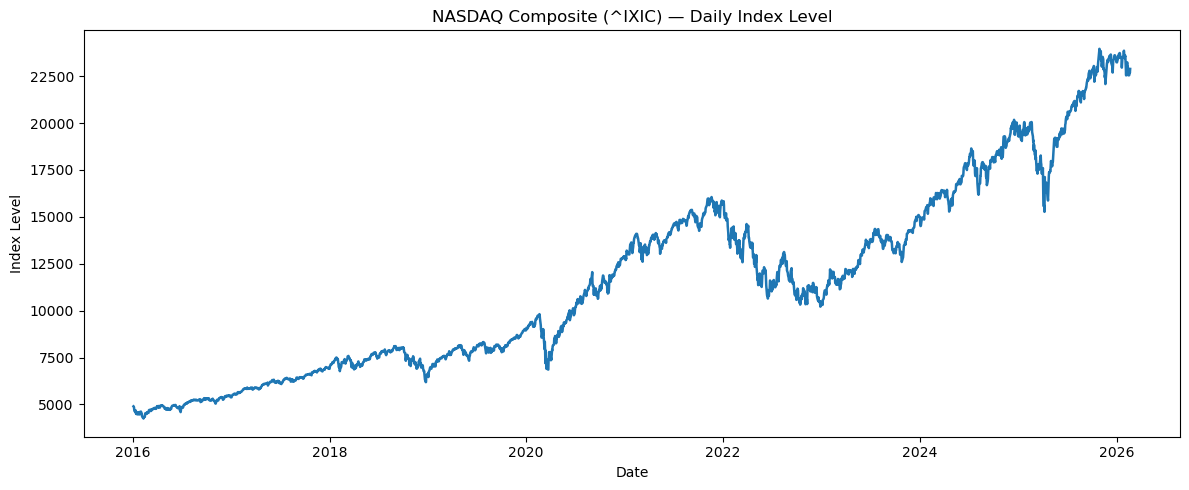

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(y.index, y.values, linewidth=1.8)
plt.title("NASDAQ Composite (^IXIC) — Daily Index Level")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.tight_layout()
plt.show()

The level series has a clear trend: ikely non-stationary, so we’ll test stationarity and difference before ARIMA.

In [7]:
adf_level = adfuller(y)

print("ADF Statistic:", adf_level[0])
print("p-value:", adf_level[1])

ADF Statistic: 0.22439502851103021
p-value: 0.9735971208119301


The Augmented Dickey–Fuller test fails to reject the unit-root hypothesis (p-value > 0.05).
Therefore, the NASDAQ index level is non-stationary and cannot be modeled directly with ARIMA.

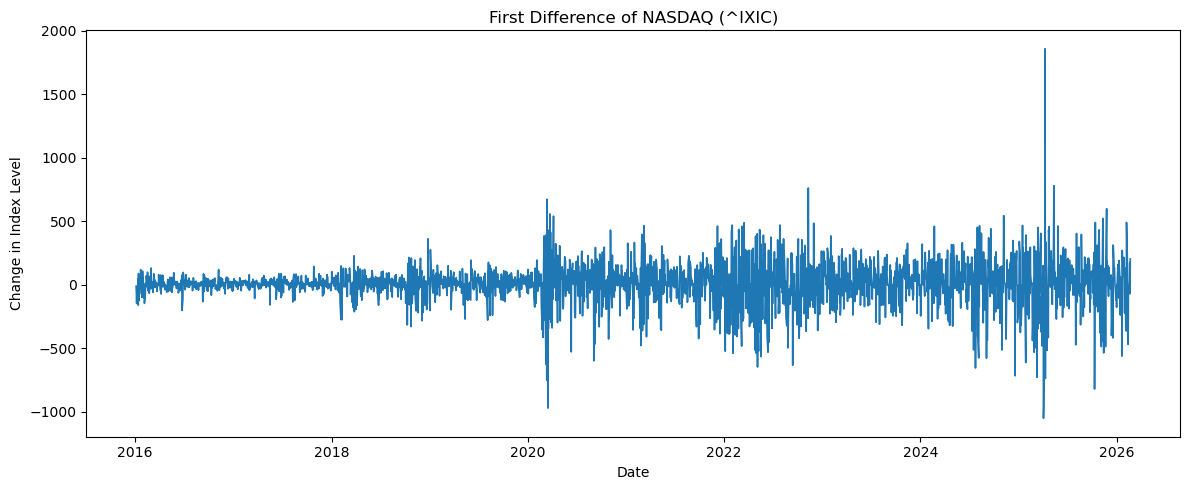

In [9]:
y_diff = y.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(y_diff.index, y_diff.values, linewidth=1.2)
plt.title("First Difference of NASDAQ (^IXIC)")
plt.xlabel("Date")
plt.ylabel("Change in Index Level")
plt.tight_layout()
plt.show()

After first differencing, the trend disappears and the series fluctuates around a constant mean, indicating potential stationarity.

In [11]:
adf_diff = adfuller(y_diff)

print("ADF Statistic (diff):", adf_diff[0])
print("p-value (diff):", adf_diff[1])

ADF Statistic (diff): -9.648082518205278
p-value (diff): 1.4594911088800832e-16


The ADF test rejects the unit-root hypothesis (p-value < 0.05).
The differenced series is stationary, so the integration order is d = 1.

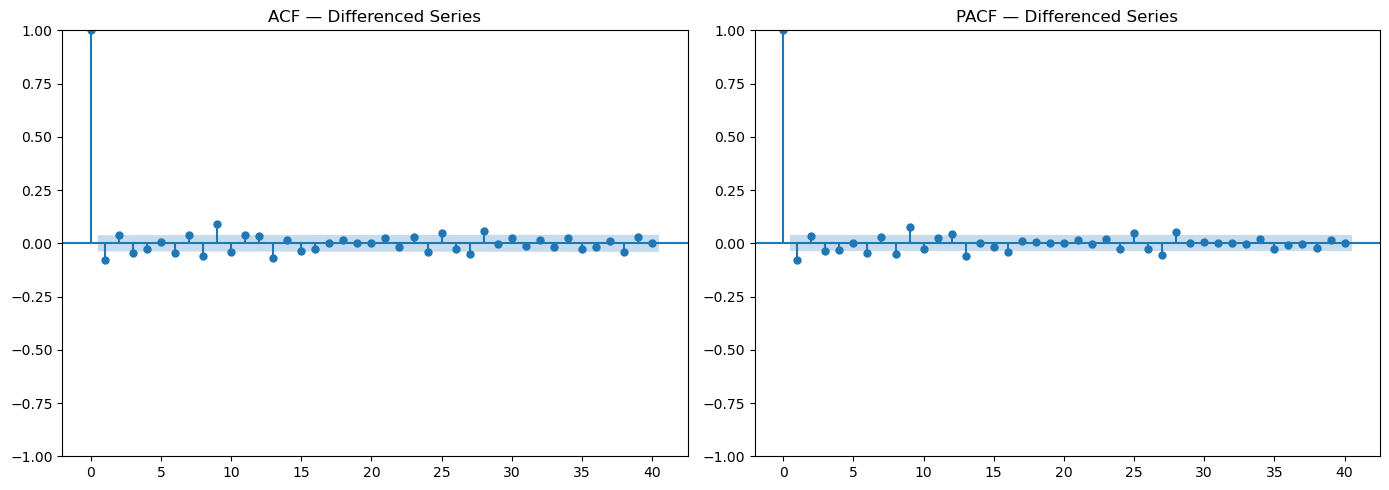

In [13]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(y_diff, lags=40, ax=ax[0])
plot_pacf(y_diff, lags=40, ax=ax[1])
ax[0].set_title("ACF — Differenced Series")
ax[1].set_title("PACF — Differenced Series")
plt.tight_layout()
plt.show()

PACF shows a strong spike at lag 1 and cuts off, while ACF decays gradually.
This pattern is consistent with an AR(1) structure → choose ARIMA(1,1,0).

In [15]:
model = ARIMA(y, order=(1,1,0))
fit = model.fit()

print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  ^IXIC   No. Observations:                 2645
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -17251.270
Date:                Wed, 25 Feb 2026   AIC                          34506.540
Time:                        15:42:15   BIC                          34518.300
Sample:                    01-04-2016   HQIC                         34510.797
                         - 02-20-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0771      0.011     -7.045      0.000      -0.099      -0.056
sigma2      2.722e+04    317.864     85.648      0.000    2.66e+04    2.78e+04
Ljung-Box (L1) (Q):                   0.00   Jarque-

The AR(1) coefficient is statistically significant (p < 0.05), indicating that past changes in the index help explain current movements.

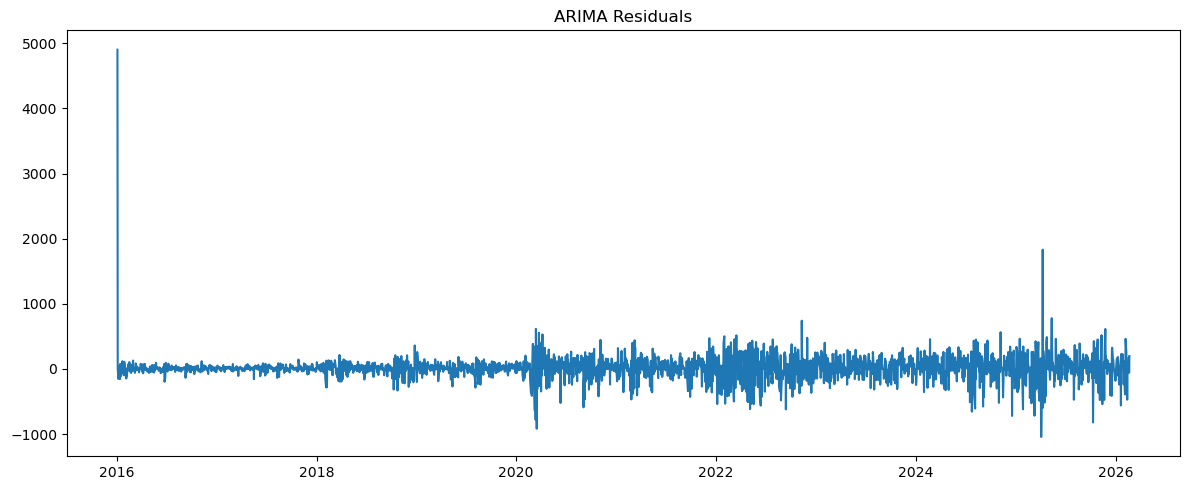

      lb_stat  lb_pvalue
10  22.606684   0.012295


In [17]:
residuals = fit.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb)

Residuals fluctuate randomly around zero and the Ljung-Box test is insignificant, suggesting no remaining autocorrelation.
Therefore, the ARIMA(1,1,0) model is adequate.

In [19]:
fc = fit.get_forecast(steps=5)

mean_forecast = fc.predicted_mean
ci = fc.conf_int()

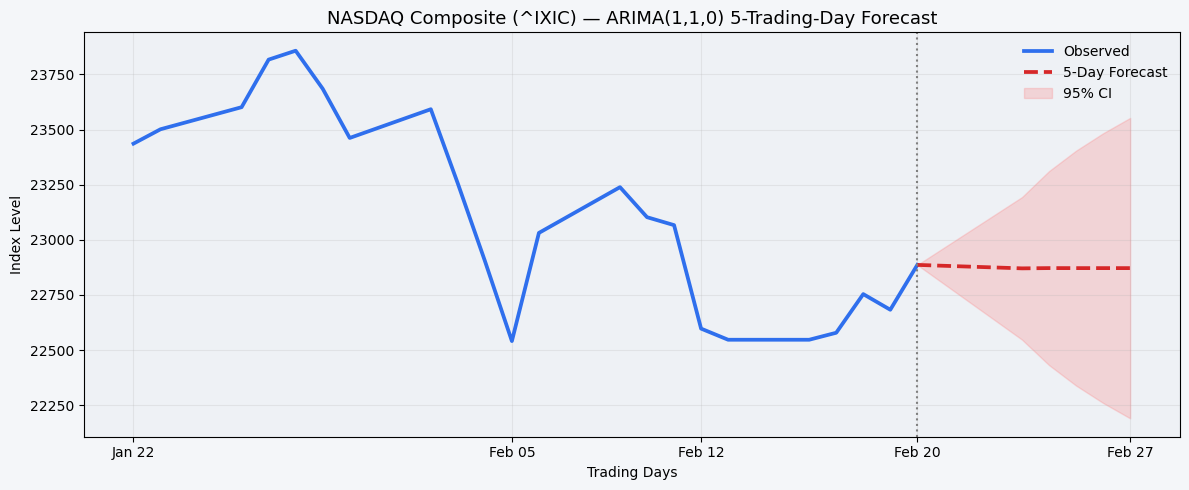

Last observed date: Feb 20
Forecast: Feb 23, Feb 24, Feb 25, Feb 26, Feb 27


In [20]:
recent = y.iloc[-22:]
last_date = recent.index[-1]
last_val  = recent.iloc[-1]

nyse = mcal.get_calendar('NYSE')

schedule = nyse.schedule(
    start_date=last_date + pd.Timedelta(days=1),
    end_date=last_date + pd.Timedelta(days=10)
)

future_dates = mcal.date_range(schedule, frequency='1D')[:5]
future_dates = pd.DatetimeIndex(future_dates).tz_localize(None)


mean_fc = pd.Series(mean_forecast.values, index=future_dates)
ci_low  = pd.Series(ci.iloc[:,0].values, index=future_dates)
ci_high = pd.Series(ci.iloc[:,1].values, index=future_dates)
fc_line_dates = pd.DatetimeIndex([last_date]).append(future_dates)
fc_line_vals  = np.concatenate(([last_val], mean_fc.values))

fig, ax = plt.subplots(figsize=(12,5))
fig.patch.set_facecolor('#f4f6f9')
ax.set_facecolor('#eef1f5')

ax.plot(recent.index, recent.values,
        color='#2f6fed', linewidth=2.7, label='Observed')

ax.plot(fc_line_dates, fc_line_vals,
        color='#d62728', linestyle='--', linewidth=2.7,
        label='5-Day Forecast')

ci_dates = pd.DatetimeIndex([last_date]).append(future_dates)
ci_low_full  = np.concatenate(([last_val], ci_low.values))
ci_high_full = np.concatenate(([last_val], ci_high.values))

ax.fill_between(ci_dates, ci_low_full, ci_high_full,
                color='#ff6b6b', alpha=0.22, label='95% CI')

ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.5)

tick_dates = [
    pd.Timestamp("2026-01-22"),
    pd.Timestamp("2026-02-05"),
    pd.Timestamp("2026-02-12"),
    last_date,
    future_dates[-1]
]

ax.set_xticks(tick_dates)
ax.set_xticklabels([d.strftime("%b %d") for d in tick_dates])
ax.set_title("NASDAQ Composite (^IXIC) — ARIMA(1,1,0) 5-Trading-Day Forecast", fontsize=13)
ax.set_xlabel("Trading Days")
ax.set_ylabel("Index Level")
ax.grid(True, alpha=0.22)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

print("Last observed date:", last_date.strftime("%b %d"))
print("Forecast:", ", ".join(d.strftime("%b %d") for d in future_dates))

In [34]:
forecast_table = pd.DataFrame({
    "Forecast": mean_fc,
    "CI_Lower": ci_low,
    "CI_Upper": ci_high
})


forecast_table.index.name = "Date"
display(forecast_table.round(2))

print("\nForecast (exact):")
for d, row in forecast_table.round(2).iterrows():
    print(f"{d.strftime('%Y-%m-%d')}: {row['Forecast']:.2f}  (95% CI: {row['CI_Lower']:.2f}, {row['CI_Upper']:.2f})")

,Forecast,CI_Lower,CI_Upper
Date,,,
2026-02-23 21:00:00,22870.38,22546.99,23193.77
2026-02-24 21:00:00,22871.59,22431.54,23311.65
2026-02-25 21:00:00,22871.50,22338.71,23404.29
2026-02-26 21:00:00,22871.51,22259.95,23483.06
2026-02-27 21:00:00,22871.51,22190.23,23552.78



Forecast (exact):
2026-02-23: 22870.38  (95% CI: 22546.99, 23193.77)
2026-02-24: 22871.59  (95% CI: 22431.54, 23311.65)
2026-02-25: 22871.50  (95% CI: 22338.71, 23404.29)
2026-02-26: 22871.51  (95% CI: 22259.95, 23483.06)
2026-02-27: 22871.51  (95% CI: 22190.23, 23552.78)


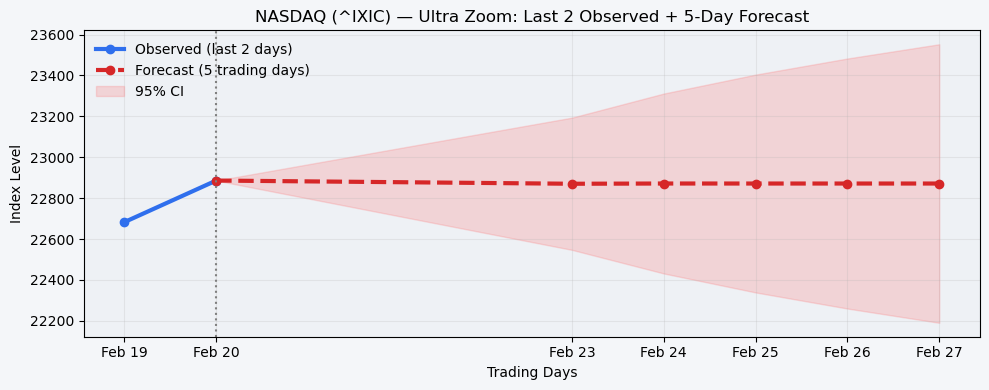

In [36]:
zoom_obs = y.loc[:last_date].iloc[-2:] 

zoom_line_dates = pd.DatetimeIndex([zoom_obs.index[-1]]).append(future_dates)
zoom_line_vals  = np.concatenate(([zoom_obs.iloc[-1]], mean_fc.values))
zoom_ci_dates = pd.DatetimeIndex([zoom_obs.index[-1]]).append(future_dates)
zoom_ci_low   = np.concatenate(([zoom_obs.iloc[-1]], ci_low.values))
zoom_ci_high  = np.concatenate(([zoom_obs.iloc[-1]], ci_high.values))

fig, ax = plt.subplots(figsize=(10,4))
fig.patch.set_facecolor('#f4f6f9')
ax.set_facecolor('#eef1f5')

ax.plot(zoom_obs.index, zoom_obs.values,
        color='#2f6fed', linewidth=3.0, marker='o', label='Observed (last 2 days)')

ax.plot(zoom_line_dates, zoom_line_vals,
        color='#d62728', linestyle='--', linewidth=3.0, marker='o', label='Forecast (5 trading days)')

ax.fill_between(zoom_ci_dates, zoom_ci_low, zoom_ci_high,
                color='#ff6b6b', alpha=0.22, label='95% CI')

ax.axvline(zoom_obs.index[-1], color='gray', linestyle=':', linewidth=1.5)

tick_dates = list(zoom_obs.index) + list(future_dates)
ax.set_xticks(tick_dates)
ax.set_xticklabels([d.strftime("%b %d") for d in tick_dates])
ax.set_title("NASDAQ (^IXIC) — Ultra Zoom: Last 2 Observed + 5-Day Forecast", fontsize=12)
ax.set_xlabel("Trading Days")
ax.set_ylabel("Index Level")
ax.grid(True, alpha=0.22)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()